F:\Anaconda\envs\new_env\lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


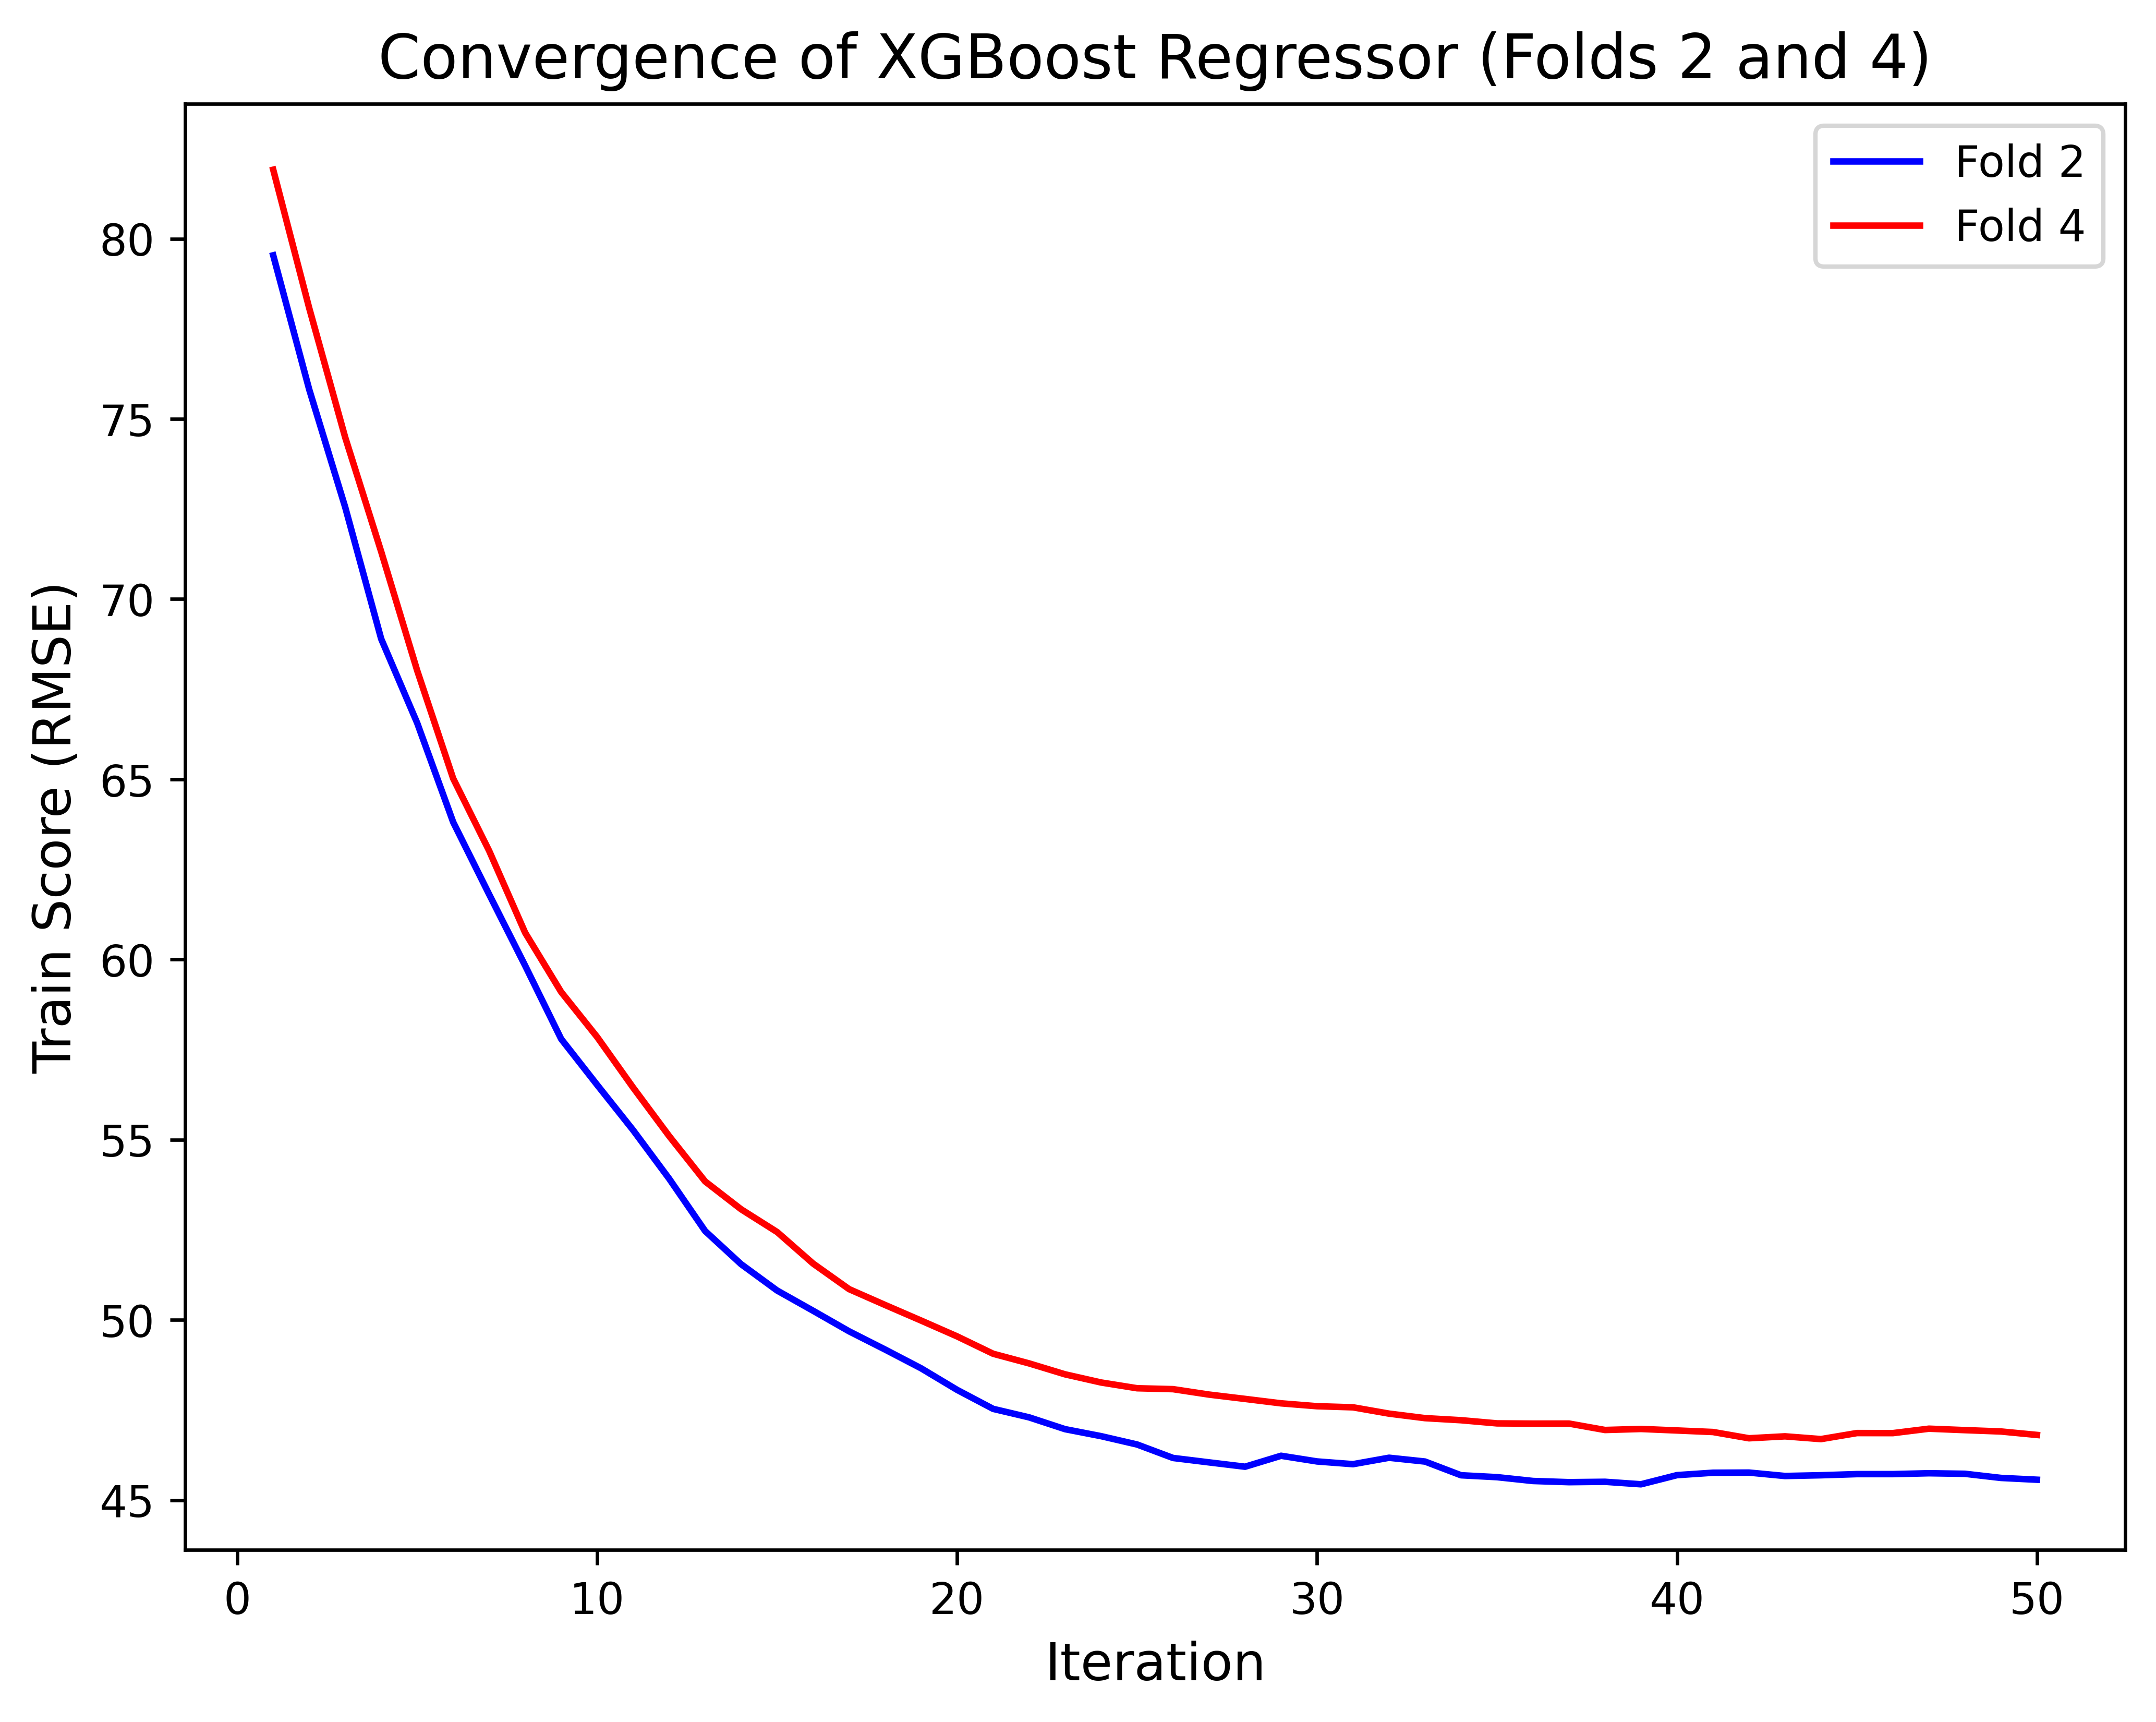

Analysis complete and results saved.


In [22]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBRegressor, plot_importance
import matplotlib.pyplot as plt
from openpyxl import load_workbook

# 设置参数
params = {
    'objective': 'reg:squarederror',
    'gamma': 0.1,
    'learning_rate': 0.1,
    'max_depth': 3,
    'n_estimators': 50,
    'random_state': 200
}

# 读取数据
df = pd.read_excel('qf_models/train_set_new.xlsx', index_col=0)
X = df.drop(columns=['Precipitate Distribution', 'Habit Plane', 'Yield_Strength', 'Tensile_Strength (UTS)', '追踪编号'])
y = df['Yield_Strength']

# 检查数据是否包含 NaN 或其他异常值
if X.isnull().values.any() or y.isnull().values.any():
    raise ValueError("数据集包含 NaN 或其他异常值，请清理数据。")

# 分箱
bins = np.linspace(y.min(), y.max(), 11)
y_binned = np.digitize(y, bins)

# 初始化 StratifiedKFold
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=200)

# 初始化 XGBRegressor
model = XGBRegressor(**params)

# 存储收敛数据
convergence_data = []

index = 0
for train_index, test_index in skf.split(X, y_binned):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    index += 1

    if index in [2, 4]:
        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

        # 保存模型收敛信息
        evals_result = model.evals_result()
        convergence_data.append({
            "Fold": index,
            "Iteration": list(range(1, len(evals_result['validation_0']['rmse']) + 1)),
            "Train Score": evals_result['validation_0']['rmse']
        })

# 保存收敛数据到 Excel
convergence_df = pd.concat([pd.DataFrame(data) for data in convergence_data], ignore_index=True)
convergence_save_path = "convergence_data_xgboost.xlsx"
convergence_df.to_excel(convergence_save_path, index=False)

# 绘制收敛曲线
plt.figure(figsize=(8, 6), dpi=600)
colors = {2: "blue", 4: "red"}

for fold_data in convergence_data:
    fold_number = fold_data["Fold"]
    color = colors[fold_number]
    plt.plot(fold_data["Iteration"], fold_data["Train Score"], label=f'Fold {fold_number}', color=color)

plt.title('Convergence of XGBoost Regressor (Folds 2 and 4)', fontsize=14)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Train Score (RMSE)', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend()
plt.savefig('qf_xgboost_convergence.png')
plt.show()

print("Analysis complete and results saved.")


F:\Anaconda\envs\new_env\lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


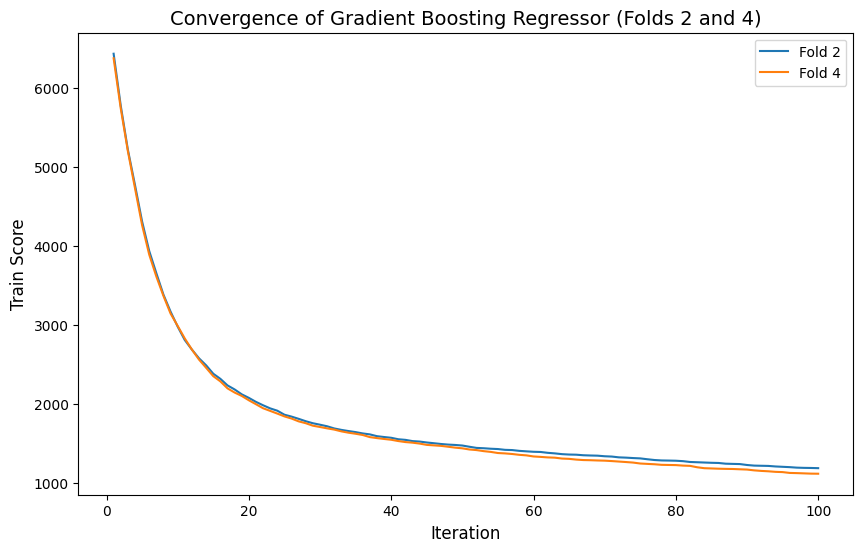

In [4]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import GradientBoostingRegressor
import matplotlib.pyplot as plt
from openpyxl import load_workbook
from openpyxl.utils.dataframe import dataframe_to_rows

# 设置参数
params = {
    'alpha': 0.9,
    'learning_rate': 0.1,
    'loss': 'squared_error',
    'max_depth': 3,
    'n_estimators': 100,
    'random_state': 200
}

# 读取数据
df = pd.read_excel('qf_models/train_set_new.xlsx', index_col=0)
X = df.drop(columns=['Precipitate Distribution', 'Habit Plane', 'Yield_Strength', 'Tensile_Strength (UTS)', '追踪编号'])
y = df['Yield_Strength']

# 检查数据是否包含 NaN 或其他异常值
if X.isnull().values.any() or y.isnull().values.any():
    raise ValueError("数据集包含 NaN 或其他异常值，请清理数据。")

# 分箱
bins = np.linspace(y.min(), y.max(), 11)
y_binned = np.digitize(y, bins)

# 初始化 StratifiedKFold
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=200)

# 初始化 GradientBoostingRegressor
model = GradientBoostingRegressor(**params)

# 存储收敛数据
convergence_data = []

index = 0
for train_index, test_index in skf.split(X, y_binned):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    index += 1

    if index in [2, 4]:
        model.fit(X_train, y_train)

        # 保存模型收敛信息
        train_score = model.train_score_
        convergence_data.append({
            "Fold": index,
            "Iteration": list(range(1, len(train_score) + 1)),
            "Train Score": train_score
        })

# 保存收敛数据到 Excel
convergence_df = pd.concat([pd.DataFrame(data) for data in convergence_data], ignore_index=True)
convergence_save_path = "convergence_data_gboost.xlsx"
convergence_df.to_excel(convergence_save_path, index=False)

# 绘制收敛曲线
plt.figure(figsize=(10, 6))
for fold_data in convergence_data:
    plt.plot(fold_data["Iteration"], fold_data["Train Score"], label=f'Fold {fold_data["Fold"]}')
plt.title('Convergence of Gradient Boosting Regressor (Folds 2 and 4)', fontsize=14)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Train Score', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend()
plt.savefig('qf_gboost_convergence.png')
plt.show()


F:\Anaconda\envs\new_env\lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


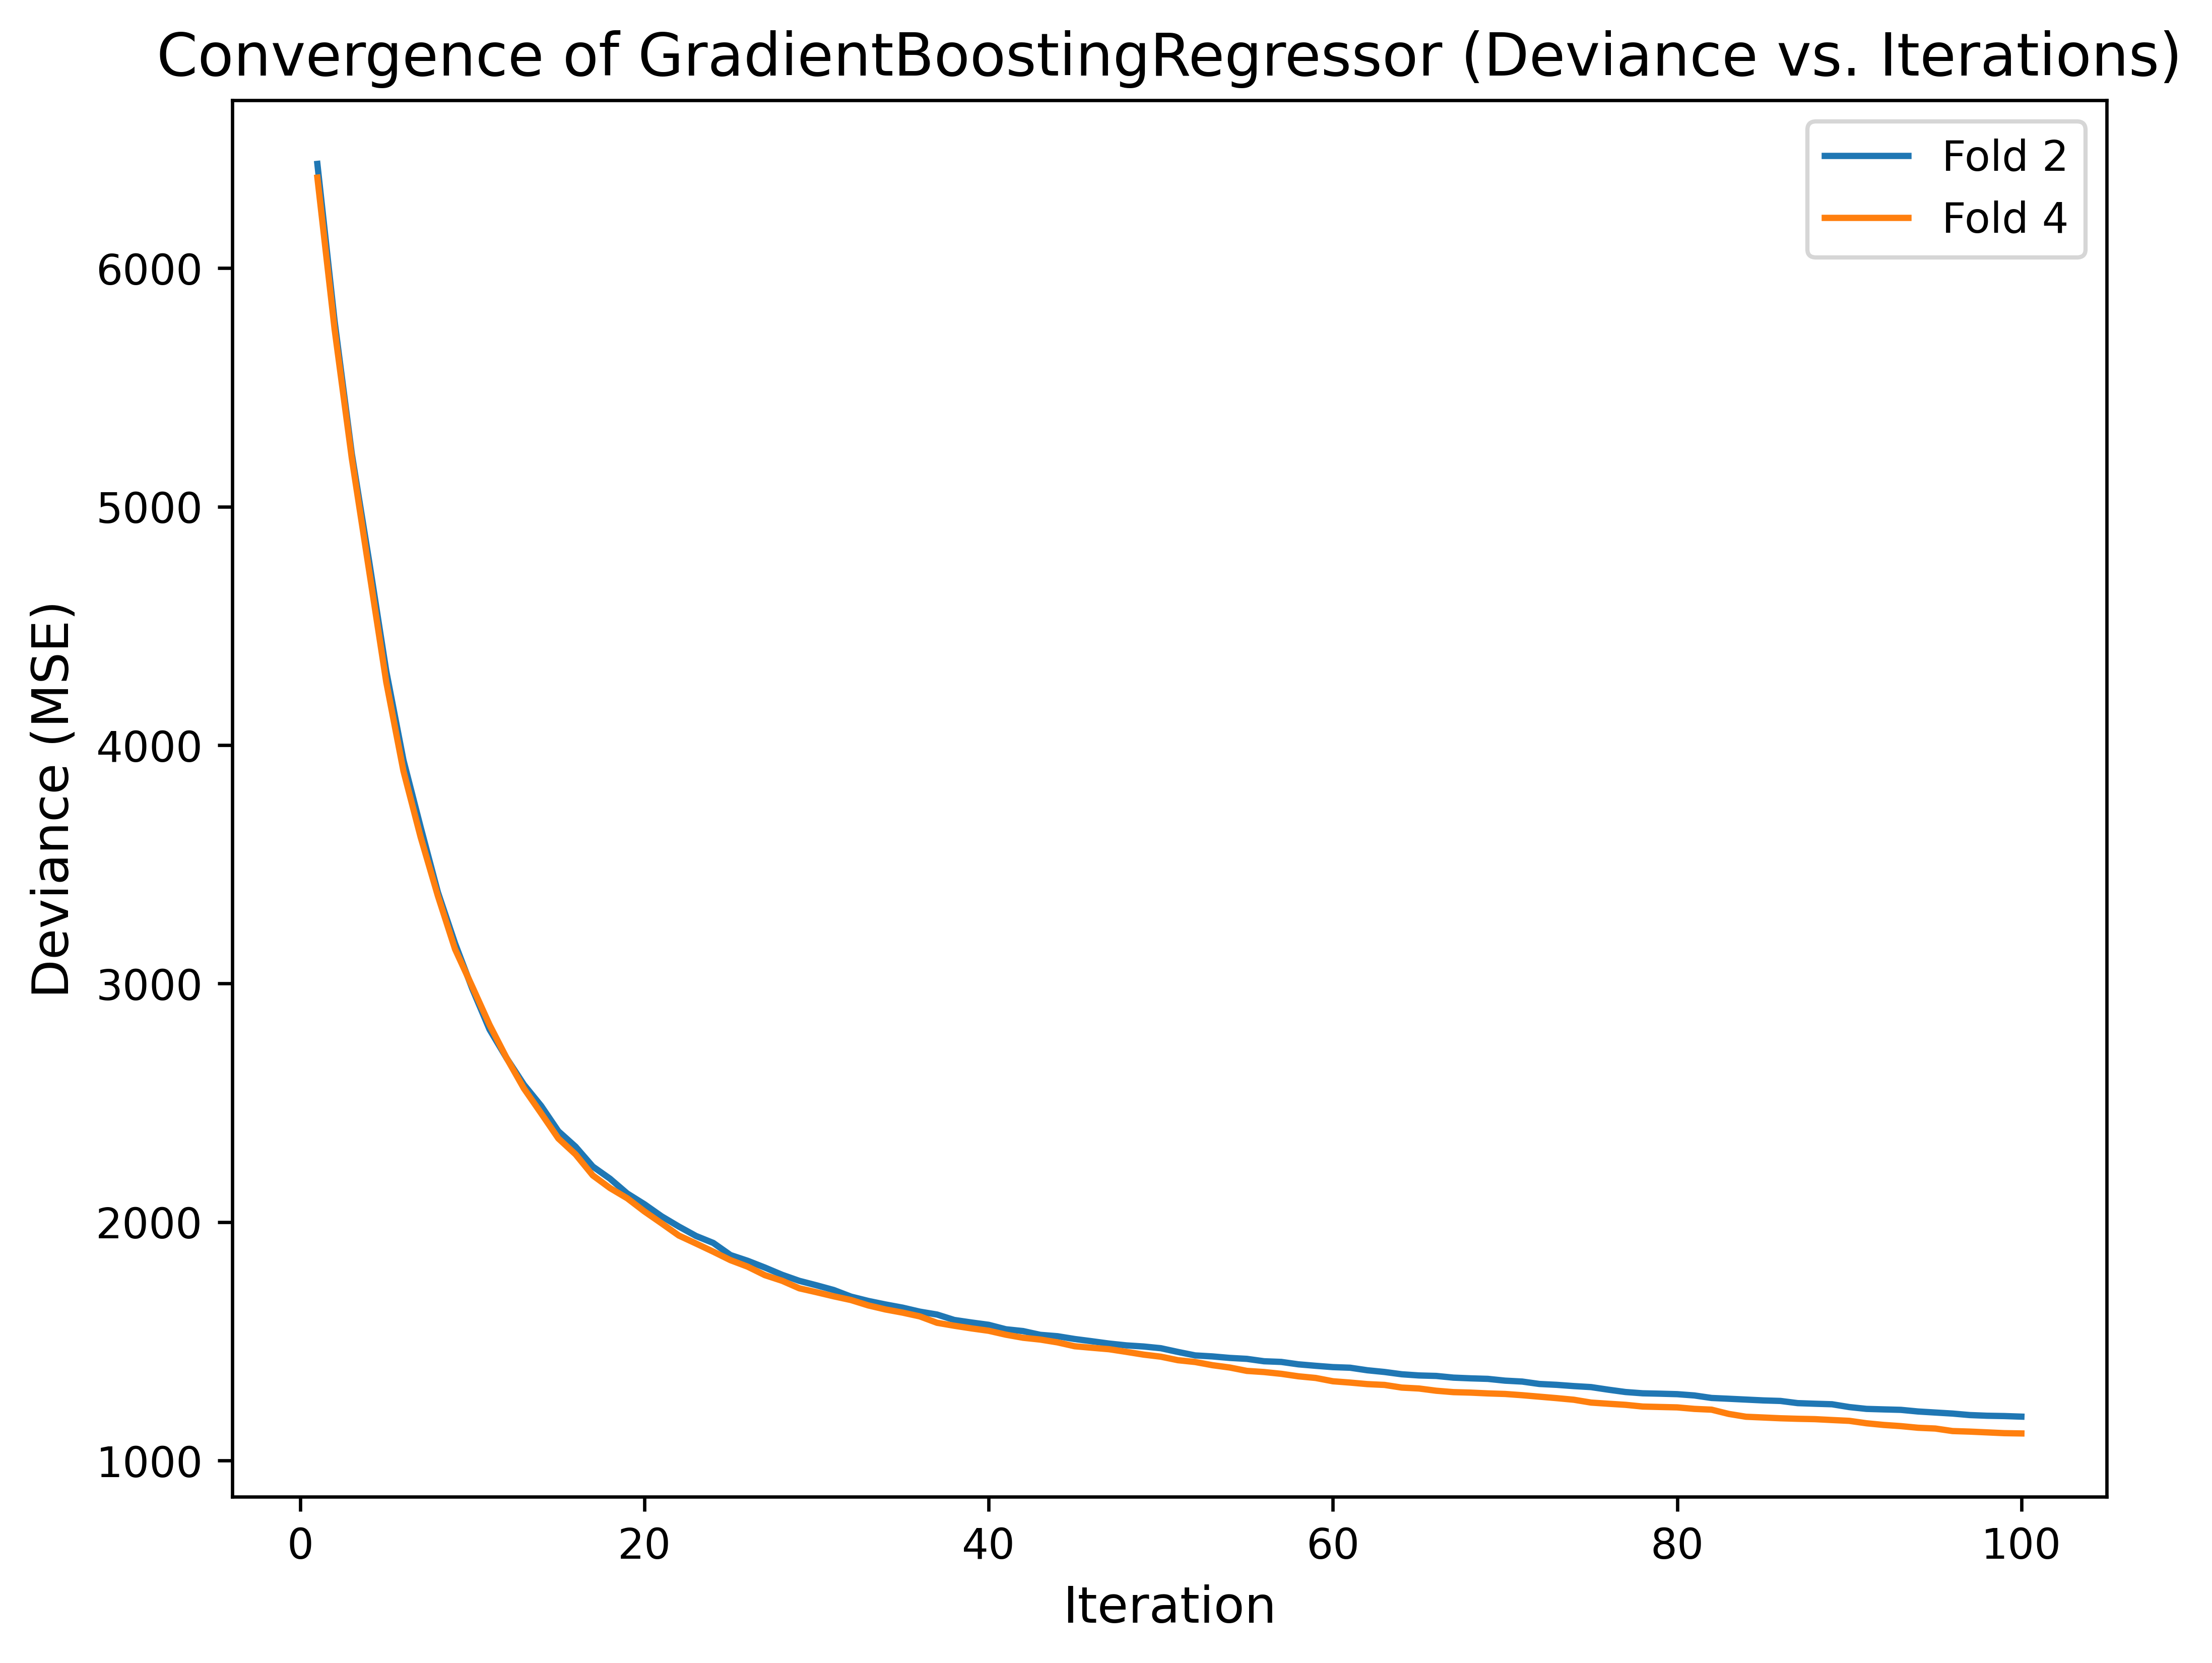

Analysis complete and results saved.


In [12]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import GradientBoostingRegressor
import matplotlib.pyplot as plt
from openpyxl import load_workbook

# 设置参数
params = {
    'alpha': 0.9,
    'learning_rate': 0.1,
    'loss': 'squared_error',
    'max_depth': 3,
    'n_estimators': 100,
    'random_state': 200
}

# 读取数据
df = pd.read_excel('qf_models/train_set_new.xlsx', index_col=0)
X = df.drop(columns=['Precipitate Distribution', 'Habit Plane', 'Yield_Strength', 'Tensile_Strength (UTS)', '追踪编号'])
y = df['Yield_Strength']

# 检查数据是否包含 NaN 或其他异常值
if X.isnull().values.any() or y.isnull().values.any():
    raise ValueError("数据集包含 NaN 或其他异常值，请清理数据。")

# 分箱
bins = np.linspace(y.min(), y.max(), 11)
y_binned = np.digitize(y, bins)

# 初始化 StratifiedKFold
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=200)

# 存储收敛数据
convergence_data = []

index = 0
for train_index, test_index in skf.split(X, y_binned):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    index += 1

    if index in [2, 4]:
        gboost_model = GradientBoostingRegressor(**params)
        gboost_model.fit(X_train, y_train)

        # 保存模型收敛信息
        train_score = gboost_model.train_score_
        convergence_data.append({
            "Model": "GradientBoostingRegressor",
            "Fold": index,
            "Iteration": list(range(1, len(train_score) + 1)),
            "Deviance": train_score
        })

# 保存收敛数据到 Excel
convergence_df = pd.concat([pd.DataFrame(data) for data in convergence_data], ignore_index=True)
convergence_save_path = "convergence_data_gboost.xlsx"
convergence_df.to_excel(convergence_save_path, index=False)

# 绘制收敛曲线
plt.figure(figsize=(8, 6),dpi = 600)
for fold_data in convergence_data:
    fold_number = fold_data["Fold"]
    plt.plot(fold_data["Iteration"], fold_data["Deviance"], label=f'Fold {fold_number}')
plt.title('Convergence of GradientBoostingRegressor (Deviance vs. Iterations)', fontsize=14)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Deviance (MSE)', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend()
plt.savefig('gboost_deviance_convergence.png')
plt.show()

print("Analysis complete and results saved.")


F:\Anaconda\envs\new_env\lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


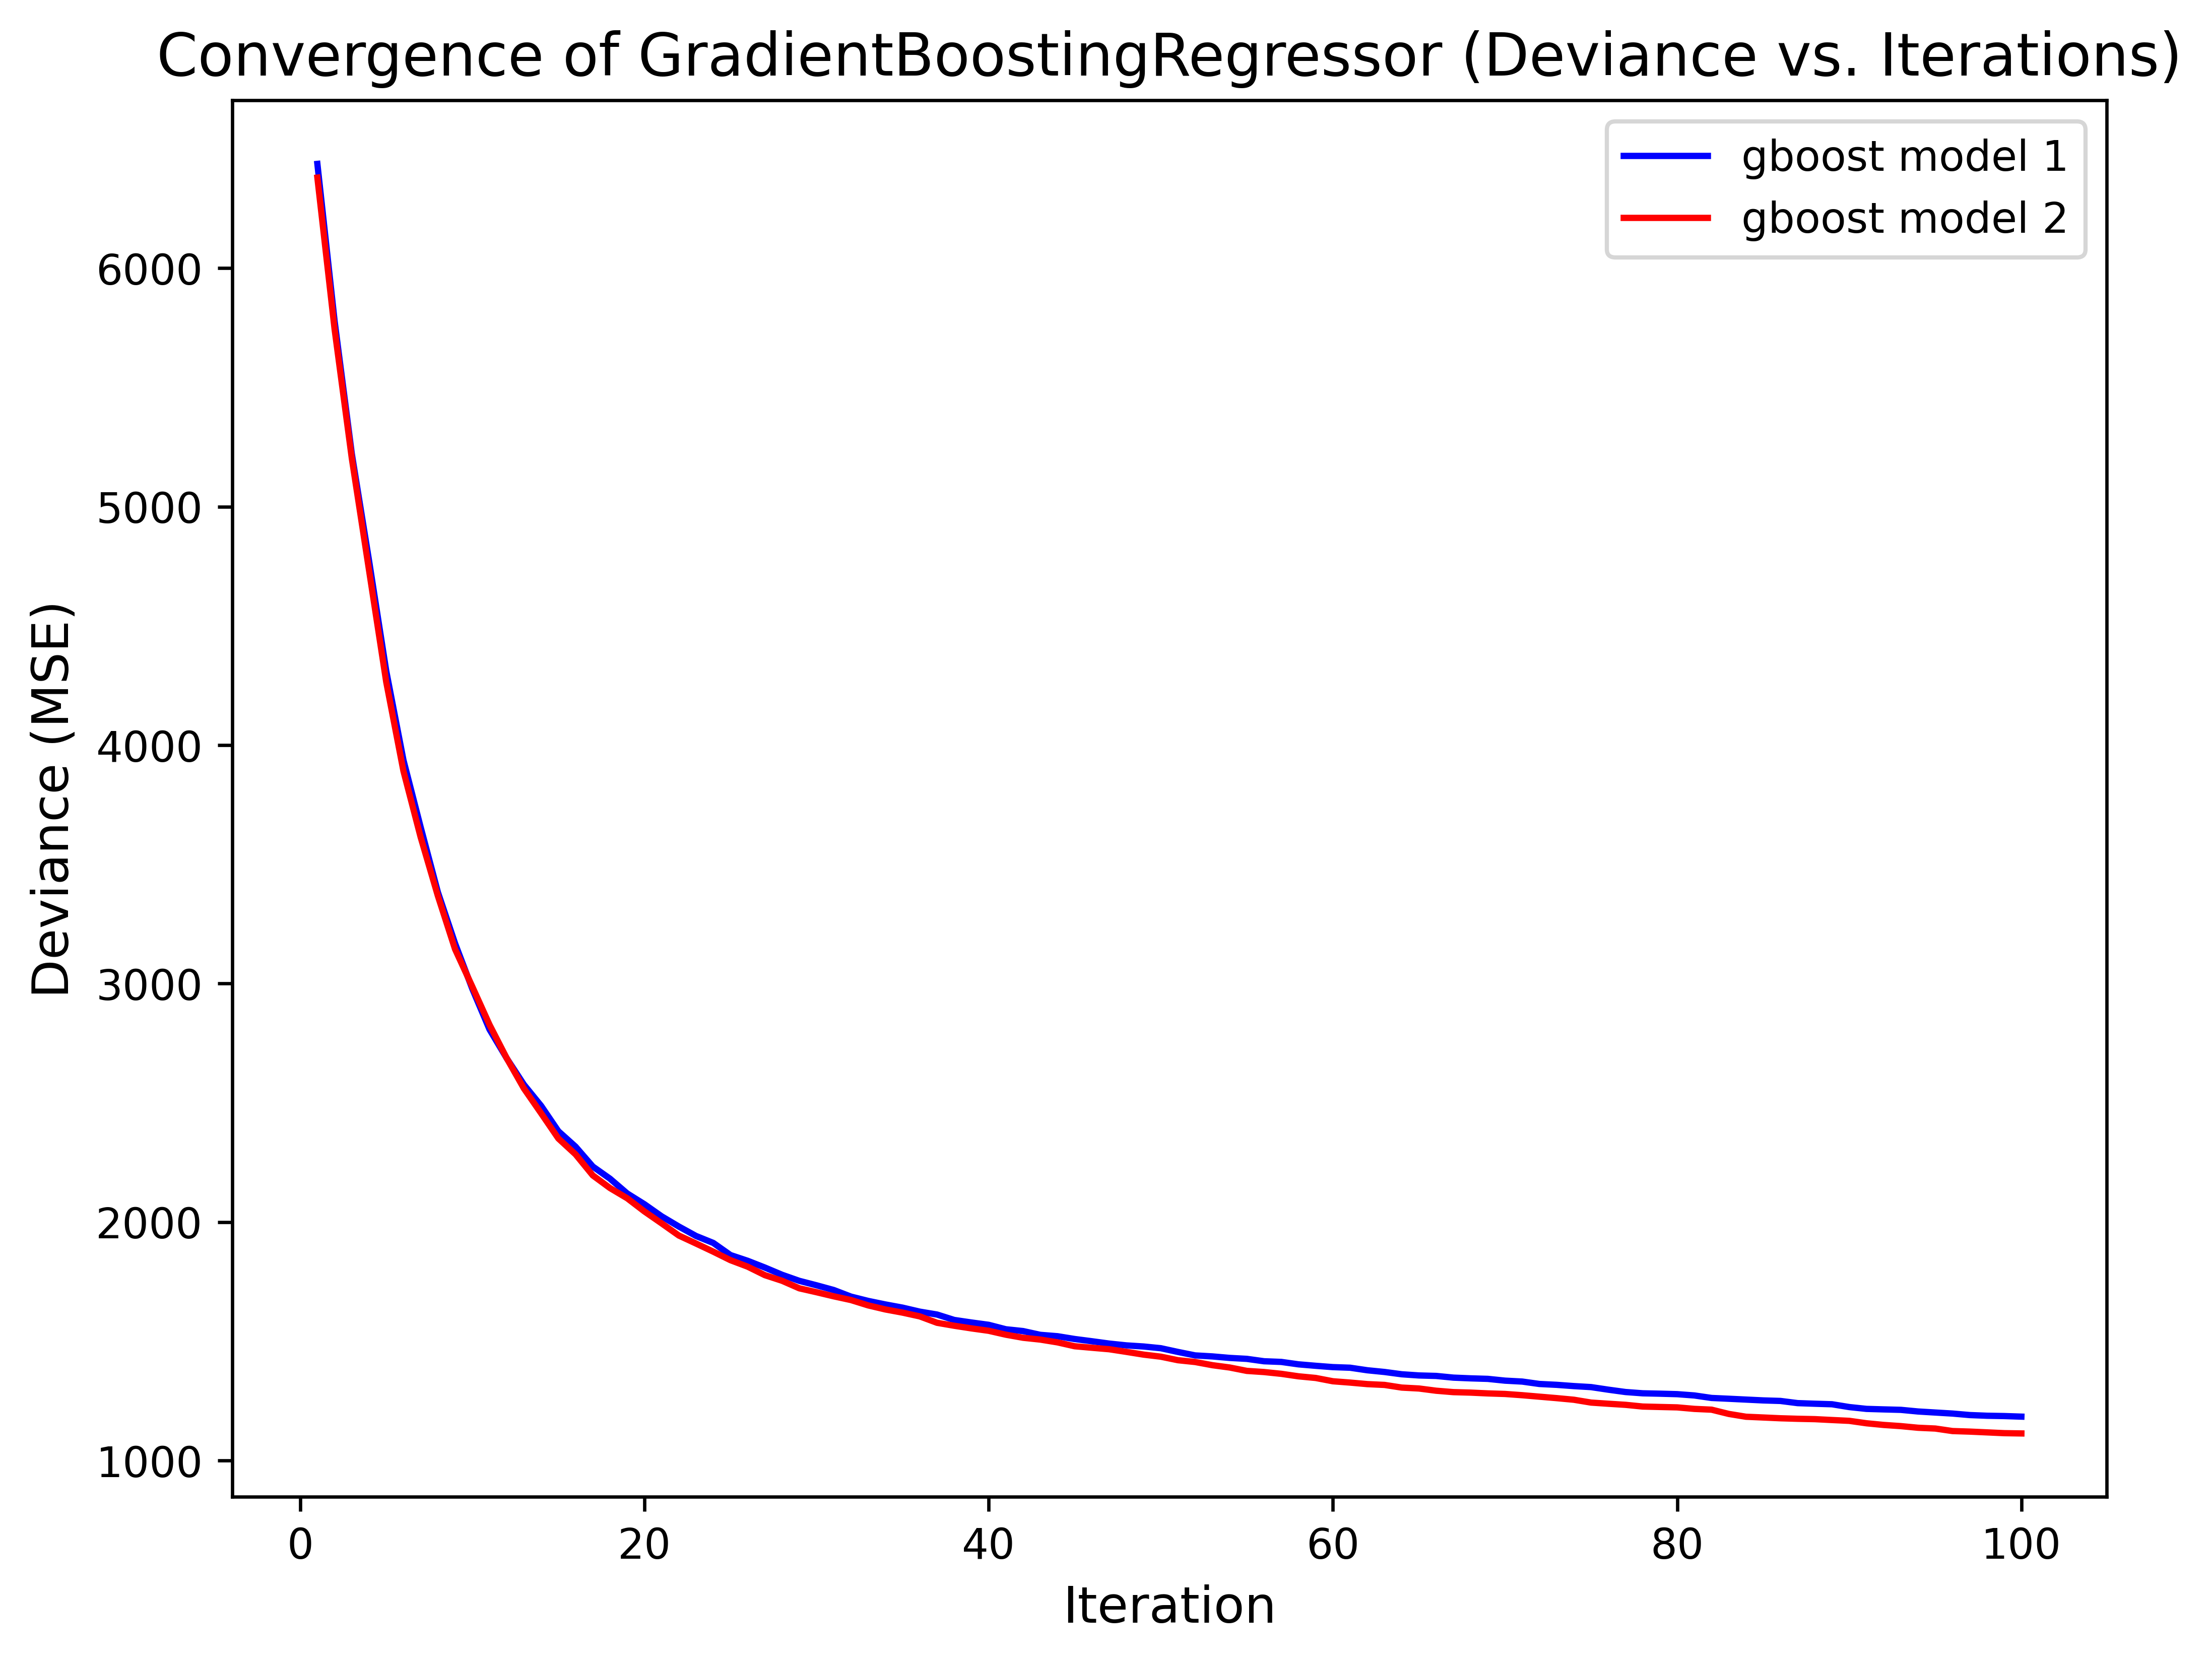

Analysis complete and results saved.


In [21]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import GradientBoostingRegressor
import matplotlib.pyplot as plt
from openpyxl import load_workbook

# 设置参数
params = {
    'alpha': 0.9,
    'learning_rate': 0.1,
    'loss': 'squared_error',
    'max_depth': 3,
    'n_estimators': 100,
    'random_state': 200
}

# 读取数据
df = pd.read_excel('qf_models/train_set_new.xlsx', index_col=0)
X = df.drop(columns=['Precipitate Distribution', 'Habit Plane', 'Yield_Strength', 'Tensile_Strength (UTS)', '追踪编号'])
y = df['Yield_Strength']

# 检查数据是否包含 NaN 或其他异常值
if X.isnull().values.any() or y.isnull().values.any():
    raise ValueError("数据集包含 NaN 或其他异常值，请清理数据。")

# 分箱
bins = np.linspace(y.min(), y.max(), 11)
y_binned = np.digitize(y, bins)

# 初始化 StratifiedKFold
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=200)

# 存储收敛数据
convergence_data = []

index = 0
for train_index, test_index in skf.split(X, y_binned):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    index += 1

    if index in [2, 4]:
        gboost_model = GradientBoostingRegressor(**params)
        gboost_model.fit(X_train, y_train)

        # 保存模型收敛信息
        train_score = gboost_model.train_score_
        convergence_data.append({
            "Model": "GradientBoostingRegressor",
            "Fold": index,
            "Iteration": list(range(1, len(train_score) + 1)),
            "Deviance": train_score
        })

# 保存收敛数据到 Excel
convergence_df = pd.concat([pd.DataFrame(data) for data in convergence_data], ignore_index=True)
convergence_save_path = "convergence_data_gboost.xlsx"
convergence_df.to_excel(convergence_save_path, index=False)

# 绘制收敛曲线
plt.figure(figsize=(8, 6), dpi=600)
colors = {2: "blue", 4: "red"}

for fold_data in convergence_data:
    fold_number = fold_data["Fold"]
    color = colors[fold_number]
    plt.plot(fold_data["Iteration"], fold_data["Deviance"], label=f'gboost model {int(fold_number/2)}', color=color)

plt.title('Convergence of GradientBoostingRegressor (Deviance vs. Iterations)', fontsize=14)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Deviance (MSE)', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend()
plt.savefig('gboost_deviance_convergence.png')
plt.show()

print("Analysis complete and results saved.")
